
# 🧠 Week 1 — SQL Foundations (Insurance Dataset)

## Story-Driven Analytics with DuckDB

In this notebook, we follow the **Analyst Journey**:

> Raw Data → Question → SQL → Pattern → Insight → Decision

Each section includes:
- Problem definition
- SQL solution
- Explanation
- Business insight
- Visualization (when applicable)


## 🔧 Setup: Load Data into DuckDB

In [2]:

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE TABLE insurance AS 
SELECT * FROM read_csv_auto('insurance.csv');
""")


# 🔹 Section 1 — Understanding the Data


## Question 1: What does the dataset look like?

### Goal
Get a quick feel for the structure and values.


In [4]:
con.execute('SELECT * FROM insurance LIMIT 10').df()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,True,southwest,16884.92400
1,18,male,33.770,1,False,southeast,1725.55230
2,28,male,33.000,3,False,southeast,4449.46200
3,33,male,22.705,0,False,northwest,21984.47061
4,32,male,28.880,0,False,northwest,3866.85520
5,31,female,25.740,0,False,southeast,3756.62160
6,46,female,33.440,1,False,southeast,8240.58960
7,37,female,27.740,3,False,northwest,7281.50560
8,37,male,29.830,2,False,northeast,6406.41070
9,60,female,25.840,0,False,northwest,28923.13692



### Business Insight
Before analysis, always inspect data to avoid wrong assumptions.


# 🔹 Section 2 — Basic Aggregations


## Question 2: What is the average insurance cost?

### Goal
Understand baseline cost across all customers.


In [5]:

df = con.execute("SELECT AVG(charges) AS avg_charges FROM insurance").df()
df


,avg_charges
0,13270.422265



### Insight
This gives us a benchmark for all comparisons.


# 🔥 Section 3 — Key Business Question


## Question 3: Do smokers pay more?

### Goal
Understand impact of smoking on insurance cost.


In [6]:

df = con.execute("""
SELECT smoker, AVG(charges) AS avg_charges
FROM insurance
GROUP BY smoker
""").df()

df


,smoker,avg_charges
0,False,8434.268298
1,True,32050.231832


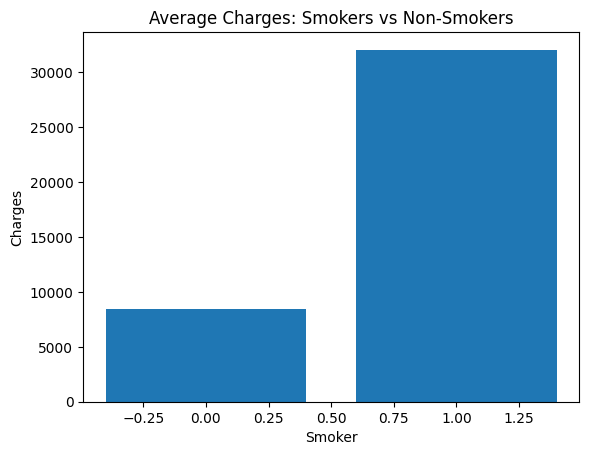

In [7]:

plt.figure()
plt.bar(df['smoker'], df['avg_charges'])
plt.title("Average Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()



### Business Insight 🚨
Smokers typically incur significantly higher costs → higher risk → higher premiums.



## Question 4: How does BMI affect cost?

### Goal
Group customers into BMI categories.


In [8]:

df = con.execute("""
SELECT 
  CASE 
    WHEN bmi < 25 THEN 'Normal'
    WHEN bmi < 30 THEN 'Overweight'
    ELSE 'Obese'
  END AS bmi_group,
  AVG(charges) AS avg_charges
FROM insurance
GROUP BY bmi_group
""").df()

df


,bmi_group,avg_charges
0,Obese,15552.335469
1,Normal,10282.224474
2,Overweight,10987.509891


In [ ]:
plt.figure()
plt.bar(df['bmi_group'], df['avg_charges'])
plt.title("Charges by BMI Category")
plt.xlabel("BMI Group")
plt.ylabel("Charges")
plt.show()

In [12]:
df = con.execute("""
SELECT 
  CASE 
    WHEN age < 20 THEN 'group-1'
    WHEN age < 30 THEN 'group-2'
    WHEN age < 40 THEN 'group-3'
    WHEN age < 50 THEN 'group-4'
    WHEN age < 60 THEN 'group-5'
    ELSE 'group-6'
  END AS age_group,
  AVG(charges) AS avg_charges
FROM insurance
GROUP BY age_group
ORDER BY avg_charges
""").df()

df

,age_group,avg_charges
0,group-1,8407.349242
1,group-2,9561.751018
2,group-3,11738.784117
3,group-4,14399.203564
4,group-5,16495.232665
5,group-6,21248.021885


In [ ]:
plt.figure()
plt.bar(df['age_group'], df['avg_charges'])
plt.title("Charges by Age Category/Group")
plt.xlabel("Age Group")
plt.ylabel("Charges")
plt.show()

---
# AVG Charges Per Gender

In [ ]:
df = con.execute("""
SELECT 
  gender,
  AVG(charges) AS avg_charges
FROM insurance
GROUP BY gender
ORDER BY avg_charges
""").df()

df

,gender,avg_charges
0,female,12569.578844
1,male,13956.751178



### Insight
Higher BMI → higher healthcare costs → pricing impact.



## Question 5: Do regions differ in cost?


In [16]:

df = con.execute("""
SELECT region, 
       AVG(charges) AS avg_charges
FROM insurance
GROUP BY region
ORDER BY avg_charges DESC
""").df()

df


,region,avg_charges
0,southeast,14735.411438
1,northeast,13406.384516
2,northwest,12417.575374
3,southwest,12346.937377


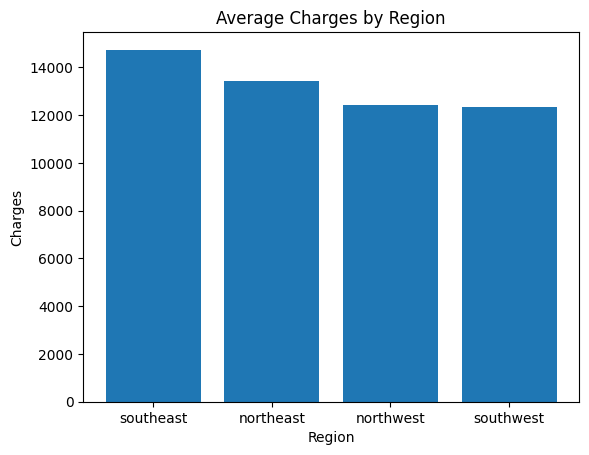

In [17]:

plt.figure()
plt.bar(df['region'], df['avg_charges'])
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()



### Insight
Geographic factors may influence pricing.


# 🔺 Section 4 — Advanced SQL


## Question 6: Who are the highest-risk customers?

### Goal
Rank customers by charges.


In [18]:

con.execute("""
SELECT *, RANK() OVER (ORDER BY charges DESC) AS rnk
FROM insurance
LIMIT 10
""").df()


,age,gender,bmi,children,smoker,region,charges,rnk
0,54,female,47.410,0,True,southeast,63770.42801,1
1,45,male,30.360,0,True,southeast,62592.87309,2
2,52,male,34.485,3,True,northwest,60021.39897,3
3,31,female,38.095,1,True,northeast,58571.07448,4
4,33,female,35.530,0,True,northwest,55135.40209,5
5,60,male,32.800,0,True,southwest,52590.82939,6
6,28,male,36.400,1,True,southwest,51194.55914,7
7,64,male,36.960,2,True,southeast,49577.66240,8
8,59,male,41.140,1,True,southeast,48970.24760,9
9,44,female,38.060,0,True,southeast,48885.13561,10



### Insight
Top-ranked individuals are high-cost → high-risk segment.


# 🧪 Section 5 — Debugging SQL


## Question 7: Why does this query fail?


In [ ]:

# Intentional error
con.execute("""
SELECT region AVG(charges)
FROM insurance
GROUP BY region
""")



### Fix the issue


In [ ]:

con.execute("""
SELECT region, AVG(charges)
FROM insurance
GROUP BY region
""").df()



# 🎯 Final Takeaways

- SQL is a thinking tool, not just syntax
- Always connect queries to business meaning
- Visualization helps communicate insights
